In [2]:
pip install torch torchvision

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 32.5 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 7.8 MB/s  0:00:00 eta 0:00:01
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.2
    Uninstalling sympy-1.13.2:━━━━━━━━━━━━━━━━━━ 0/3 [sympy]
      Successfully uninstalled sympy-1.13.2━━━━━ 0/3 [sympy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [torchvision] [torchvision]
Note: you may need to restart the kernel to use updated packages.


In [6]:
!pip install easyocr
!pip install imutils

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for imutils: filename=imutils-0.5.4-py3-none-any.whl size=25871 sha256=c59edbd51df602cd707eaf3b7c1370ea8edc65d812c6e73267df9e1ba4bb449c
  Stored in directory: /Users/yodavidchill/Library/Caches/pip/wheels/5b/76/96/ad0c321506837bef578cf3008df3916c23018435a355d9f6b1
Successfully built imutils


In [1]:
import numpy as np

In [2]:
import cv2
from matplotlib import pyplot as plt
import easyocr
import imutils

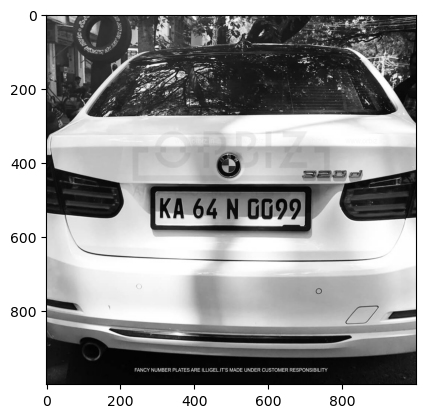

In [95]:
img = cv2.imread('image6.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))

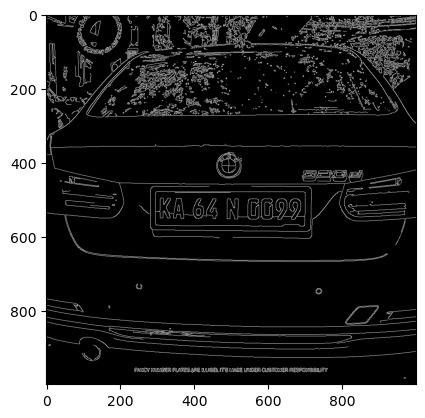

In [96]:
bfilter = cv2.bilateralFilter(gray, 11, 17, 17)
edged = cv2.Canny(bfilter, 30, 200)
plt.imshow(cv2.cvtColor(edged, cv2.COLOR_BGR2RGB)) 

In [97]:
keypoints = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours = imutils.grab_contours(keypoints)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

In [98]:
location = None
for contour in contours:
    approx = cv2.approxPolyDP(contour, 10, True)
    if len(approx) == 4:
        location = approx
        break

In [99]:
location

array([[[295, 484]],

       [[298, 570]],

       [[699, 570]],

       [[696, 480]]], dtype=int32)

In [100]:
mask = np.zeros(gray.shape, np.uint8)
new_image = cv2.drawContours(mask, [location], 0, 255, -1)
new_image = cv2.bitwise_and(img, img, mask=mask)

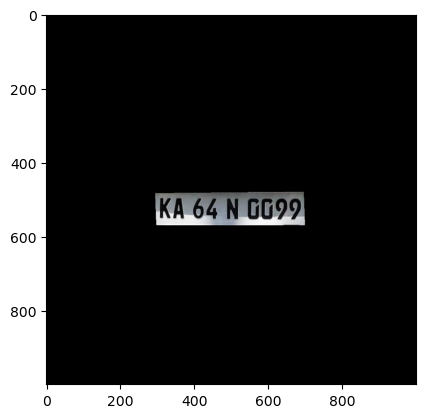

In [101]:
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))

In [102]:
(x,y) = np.where(mask==255)
(x1, y1) = (np.min(x), np.min(y))
(x2, y2) = (np.max(x), np.max(y))
cropped_img = gray[x1:x2+2, y1:y2+2]

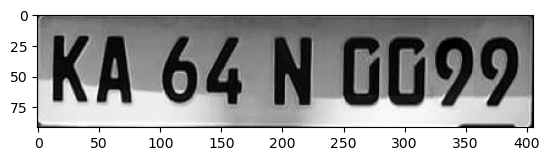

In [103]:
plt.imshow(cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB))

In [104]:
reader = easyocr.Reader(['en'])
result = reader.readtext(cropped_img)
result

[([[3, 5], [406, 5], [406, 91], [3, 91]], 'KA 64 N 00991', 0.5103214492994259)]

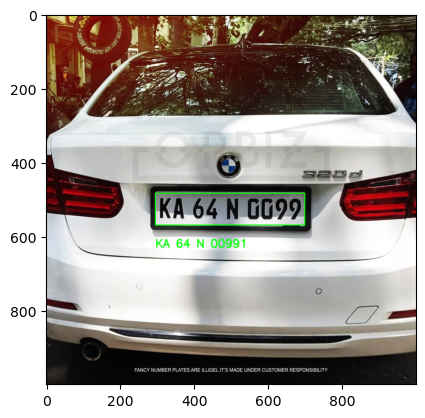

In [105]:
text = result[0][-2]
font = cv2.FONT_HERSHEY_SIMPLEX
res = cv2.putText(img, text=text, org=(approx[0][0][0], approx[1][0][1]+60), fontFace=font, fontScale=1, color=(0,255,0), thickness=2, lineType=cv2.LINE_AA)
res = cv2.rectangle(img, tuple(approx[0][0]), tuple(approx[2][0]), (0,255,0),2)
plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))